# The Annotated U-Net：医学图像分割教学版

本 notebook 以 Kvasir-SEG 息肉分割为例，讲清楚 U-Net 为什么适合语义分割、张量如何在编解码路径中流动，以及如何用 PyTorch 写出一个可运行的轻量训练流程。

> 运行准备：在 `books/annotated-unet/` 目录下执行 `bash download_kvasir.sh` 下载并解压数据。若只想理解模型结构，可以先运行到“形状验证”单元，不需要训练完整模型。

In [1]:
!bash download_kvasir.sh

[已跳过] 压缩包已存在: ./data/kvasir-seg.zip
[已跳过] 数据集目录已存在: ./data/Kvasir-SEG

数据集目录结构:
  ./data/Kvasir-SEG/
  ├── images/   (1000 张 JPEG 图像)
  └── masks/    (1000 张对应分割掩码)


## 学习目标

完成本节后，你应能做到：

1. 说明语义分割（semantic segmentation）与图像分类的差异：分类输出一个图像级标签，分割输出一个像素级掩码。
2. 解释 U-Net 的三段结构：编码器（encoder）、瓶颈层（bottleneck）、解码器（decoder）。
3. 跟踪输入图像张量 `(B, 3, H, W)` 在下采样、跳跃连接（skip connection）、上采样中的形状变化。
4. 读懂并实现 `DoubleConv`、`Down`、`Up`、`OutConv` 四个教学组件。
5. 解释 Dice Loss 为什么适合前景较少的医学分割任务，并能解读 Dice、IoU、Precision、Recall、Accuracy。
6. 跑通一个轻量验证实验，观察损失曲线和预测掩码是否符合预期。

## 研究背景
医疗影像分割是医疗影像分析中的核心任务，其目标是从 CT、MRI、超声或病理图像中自动识别并勾画器官、组织和病灶区域。分割结果能够为疾病检测、病灶测量、辅助诊断和治疗规划提供基础数据支撑，因此被认为是现代计算机辅助诊断（CAD）系统的重要组成部分，也是深度学习在医学领域最成功的应用方向之一。

医疗影像分割存在多种模态，包括了：磁共振成像（MRI），计算机断层扫描（CT），正电子发射断层成像（PET），超声心动图（Echocardiography），眼科影像，皮肤病变图像。


![medical segmentation](figures/medicalsegmentation.png)

![medical images](figures/medicalimages.png)

## 任务定义

### 任务的一般定义：每个像素都要分类

医学图像分割要回答的问题不是“图像中有没有目标”，而是“每一个像素属于哪个类别”。因此语义分割（semantic segmentation）的一般形式是：

$$
f_\theta: \mathbb{R}^{B \times 3 \times H \times W} \rightarrow \mathbb{R}^{B \times K \times H \times W}
$$

其中 $B$ 是 batch size，$K$ 是需要预测的类别数，$H,W$ 是图像高宽。输出通常是 logits，而不是最终类别标签。

如果任务是互斥多分类，例如背景、器官、病灶三类，则 `K=3`，每个像素位置有 3 个 logits。经过 softmax 后，可以得到该像素属于每个类别的概率，再取概率最大的类别作为预测标签。

### Kvasir-SEG 的特殊情况：息肉/背景二分类

本 notebook 处理的是 Kvasir-SEG 息肉分割。它只关心每个像素是否属于息肉，因此是二分类特例：

$$
f_\theta: \mathbb{R}^{B \times 3 \times H \times W} \rightarrow \mathbb{R}^{B \times 1 \times H \times W}
$$

这里输出 1 个前景 logit 通道。对这个通道做 sigmoid 后，得到每个像素属于前景（息肉）的概率；概率高于阈值的像素被预测为息肉，否则预测为背景。

### U-Net 为什么适合这类任务

U-Net 的直觉可以分成三句话：

- 编码器逐步降低空间分辨率，让深层特征看到更大的上下文。
- 解码器逐步恢复空间分辨率，把语义特征还原成像素级预测。
- 跳跃连接把浅层的边缘和纹理细节直接送回解码器，减少边界信息丢失。

医学分割常见困难包括目标形状不规则、边界模糊、前景区域远少于背景区域。U-Net 的多尺度特征与跳跃连接正好对应这些问题。


In [2]:
from pathlib import Path
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchinfo import summary
import matplotlib.pyplot as plt

print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()} | MPS: {torch.backends.mps.is_available()}")

PyTorch 2.11.0+cu128 | CUDA: True | MPS: False


In [3]:
SEED = 42
SPLIT_SEED = 58800

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(f"使用设备：{device}")

使用设备：cuda


## 数据集与任务定义

### 语义分割标签的一般形式

语义分割的标签取决于任务类型：

- 互斥多分类：每个像素只属于一个类别。模型通常输出 `(B, K, H, W)`，标签可保存为类别索引 `(B, H, W)`，训练时常用 softmax + cross entropy。
- 多标签分割：一个像素可能同时属于多个标签。模型通常输出 `(B, K, H, W)`，标签写成多热编码 `(B, K, H, W)`，训练时可使用多通道 sigmoid。
- 二分类分割：只有前景和背景。常见简化写法是输出 `(B, 1, H, W)`，用 sigmoid 表示前景概率。

### Kvasir-SEG 的当前设定

Kvasir-SEG 包含 1000 张消化内镜图像及对应的息肉二值掩码。当前数据集只标注“息肉/背景”，所以本 notebook 采用二分类语义分割设定：

- 输入图像：RGB，读取后转为 `(3, H, W)`，组 batch 后为 `(B, 3, H, W)`。
- 标签掩码：单通道二值图，读取后转为 `(1, H, W)`，组 batch 后为 `(B, 1, H, W)`。
- 标签含义：`1` 表示息肉像素，`0` 表示背景像素。

预处理策略：

- 图像统一 resize 到 `IMG_SIZE x IMG_SIZE`，再用 ImageNet 均值和方差归一化。
- 掩码使用最近邻插值（nearest），避免边界插值产生灰度类别，再阈值化为严格的 0/1。
- 数据划分使用固定随机种子，两步切分为训练/验证/测试，默认比例约为 80/10/10。


### pytorch数据集定义

In [4]:
# 支持在项目根目录或books/annotated-unet/ 下运行
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "data" / "Kvasir-SEG").exists() and (Path("books/annotated-unet/data/Kvasir-SEG")).exists():
    NOTEBOOK_DIR = Path("books/annotated-unet")

DATA_ROOT = NOTEBOOK_DIR / "data" / "Kvasir-SEG"
IMG_DIR = DATA_ROOT / "images"
MASK_DIR = DATA_ROOT / "masks"
IMG_SIZE = 128

class KvasirDataset(Dataset):
    """Kvasir-SEG 息肉分割数据集。返回 image: (3,S,S)，mask: (1,S,S)。"""

    def __init__(self, img_dir, mask_dir, img_size=128, img_paths=None):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        if img_paths is None:
            self.img_paths = sorted(self.img_dir.glob("*.jpg")) + sorted(self.img_dir.glob("*.jpeg"))
            self.img_paths = sorted(self.img_paths)
        else:
            self.img_paths = list(img_paths)

        if not self.img_paths:
            raise FileNotFoundError(
                f"未在 {self.img_dir} 找到图像。请先在 books/annotated-unet/ 下运行 bash download_kvasir.sh"
            )

        self.image_transform = transforms.Compose([
            transforms.Resize((img_size, img_size), interpolation=InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size), interpolation=InterpolationMode.NEAREST),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        mask_path = self.mask_dir / img_path.name
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        image = self.image_transform(image)
        mask = (self.mask_transform(mask) > 0.5).float()
        return image, mask

### 数据集划分

In [5]:
def split_kvasir_paths(img_dir, test_ratio=0.1, val_ratio=0.1, seed=SPLIT_SEED):
    all_paths = sorted(Path(img_dir).glob("*.jpg")) + sorted(Path(img_dir).glob("*.jpeg"))
    all_paths = sorted(all_paths)
    if not all_paths:
        raise FileNotFoundError(f"未找到图像文件：{img_dir}")

    trainval_paths, test_paths = train_test_split(
        all_paths, test_size=test_ratio, shuffle=True, random_state=seed
    )
    val_frac_inside_trainval = val_ratio / (1.0 - test_ratio)
    train_paths, val_paths = train_test_split(
        trainval_paths, test_size=val_frac_inside_trainval, shuffle=True, random_state=seed
    )
    return train_paths, val_paths, test_paths

train_paths, val_paths, test_paths = split_kvasir_paths(IMG_DIR)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

sample_set = KvasirDataset(IMG_DIR, MASK_DIR, img_size=IMG_SIZE, img_paths=train_paths[:4])
sample_image, sample_mask = sample_set[0]
print("单张图像:", tuple(sample_image.shape), sample_image.dtype)
print("单张掩码:", tuple(sample_mask.shape), sample_mask.dtype, "取值:", sample_mask.unique().tolist())

Train: 800 | Val: 100 | Test: 100
单张图像: (3, 128, 128) torch.float32
单张掩码: (1, 128, 128) torch.float32 取值: [0.0, 1.0]


### 数据样例可视化

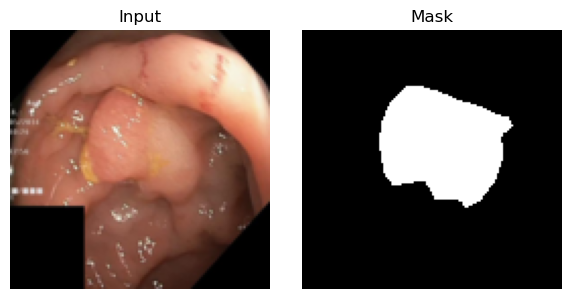

In [6]:
def denormalize(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    return image.permute(1, 2, 0).numpy().clip(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(denormalize(sample_image))
axes[0].set_title("Input")
axes[1].imshow(sample_mask.squeeze().numpy(), cmap="gray")
axes[1].set_title("Mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 损失函数定义

### 任务损失的一般形式

语义分割训练的目标，是让每个像素的预测类别接近标注类别。设模型输出 logits 为 $z=f_\theta(x)$，标签为 $y$，单张图像的像素级损失可写成：

$$
\mathcal{L}(\theta)=\frac{1}{BHW}\sum_{b=1}^{B}\sum_{h=1}^{H}\sum_{w=1}^{W}\ell\big(z_{b,:,h,w}, y_{b,h,w}\big)
$$

这里 $z_{b,:,h,w}$ 表示第 `b` 张图像在像素 `(h,w)` 处的所有类别 logits。不同任务会选择不同的 $\ell$：

- 互斥多分类分割：每个像素只属于一个类别，常用 softmax + cross entropy。logits 形状通常为 `(B, K, H, W)`，标签为 `(B, H, W)` 的类别索引。
- 多标签分割：每个像素可能同时属于多个标签，常用多通道 sigmoid + binary cross entropy。logits 和标签通常为 `(B, K, H, W)`。
- 二分类前景/背景分割：通常采用单通道sigmoid + binary cross entropy进行训练；也常结合 Dice Loss 直接优化预测区域与真实区域的重叠程度。

### Kvasir-SEG 的二分类 Dice Loss

Kvasir-SEG 的前景是息肉，背景通常占大多数。若模型把大多数像素预测为背景，像素级 accuracy 可能仍然很高，却没有真正覆盖息肉区域。因此本 notebook 使用 Dice Loss，把优化目标直接对准“预测区域与真实区域的重叠程度”。

对当前二分类设定，模型输出 logits 与标签形状均为 `(B, 1, H, W)`。先用 sigmoid 得到前景概率：

$$
p_i = \sigma(z_i), \quad y_i \in \{0,1\}
$$

其中 $i$ 遍历一个 batch 内的所有像素。软 Dice 系数定义为：

$$
\operatorname{Dice}(p,y)=\frac{2\sum_i p_i y_i + \epsilon}{\sum_i p_i + \sum_i y_i + \epsilon}
$$

对应的训练损失为：

$$
\mathcal{L}_{\text{Dice}} = 1 - \operatorname{Dice}(p,y)
$$

$\epsilon$ 是平滑项，用于避免空掩码或全背景样本导致分母为 0。Dice Loss 的值越小，表示预测前景区域与真实息肉区域越重合。

需要注意：Dice Loss 适合作为医学分割的核心目标，但它不等于所有分割任务的唯一选择。若改成互斥多分类任务，应将输出改为 `(B, K, H, W)`，并使用 `CrossEntropyLoss` 或多类别 Dice；若希望同时稳定像素级分类和区域重叠，也可以使用 `BCEWithLogitsLoss + DiceLoss` 的复合损失。

In [7]:
class DiceLoss(nn.Module):
    """Dice Loss。logits 和 targets 均为 (B, 1, H, W)。"""

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.flatten(start_dim=1)
        targets = targets.flatten(start_dim=1)
        intersection = (probs * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (
            probs.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )
        return 1.0 - dice.mean()


def dice_score(logits, targets, threshold=0.5, eps=1e-8):
    preds = (torch.sigmoid(logits) > threshold).float()
    preds = preds.flatten(start_dim=1)
    targets = targets.flatten(start_dim=1)
    intersection = (preds * targets).sum(dim=1)
    dice = (2.0 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)
    return dice.mean()

In [8]:
criterion = DiceLoss()
demo_logits = torch.randn(2, 1, 128, 128)
demo_targets = torch.zeros_like(demo_logits)
loss_value = criterion(demo_logits, demo_targets)
print(f"随机 logits 的 Dice Loss: {loss_value.item():.4f}")

随机 logits 的 Dice Loss: 0.9999


## 模型框架

下图展示 U-Net 的整体路径。编码器负责压缩，解码器负责恢复，左右同尺度特征通过跳跃连接送入解码器，并在通道维拼接。

![U-Net 架构图](figures/unet_arch.png)

读图时重点看三条信息：

- 左侧下采样路径逐步降低空间分辨率，同时增加通道数。
- 右侧上采样路径逐步恢复空间分辨率，最终输出像素级预测。
- 横向跳跃连接把浅层细节送回同尺度的解码阶段，帮助恢复边界。

以输入 `(B, 3, 256, 256)`、基础通道数 `base=64` 为例，主要张量流如下：

| 阶段/模块 | 输入形状 | 操作 | 输出形状 | 说明 |
|---|---:|---|---:|---|
| 输入 | `(B, 3, 256, 256)` | RGB 图像 | `(B, 3, 256, 256)` | PyTorch 图像默认通道在前 |
| `inc` | `(B, 3, 256, 256)` | 两次 3x3 卷积 | `(B, 64, 256, 256)` | `padding=1` 保持空间尺寸 |
| `down1` | `(B, 64, 256, 256)` | MaxPool + DoubleConv | `(B, 128, 128, 128)` | 高宽减半，通道翻倍 |
| `down2` | `(B, 128, 128, 128)` | MaxPool + DoubleConv | `(B, 256, 64, 64)` | 感受野继续增大 |
| `down3` | `(B, 256, 64, 64)` | MaxPool + DoubleConv | `(B, 512, 32, 32)` | 保存给后续 skip |
| `down4` | `(B, 512, 32, 32)` | MaxPool + DoubleConv | `(B, 1024, 16, 16)` | 最深语义特征 |
| `up1` | `(B, 1024, 16, 16)` + `(B, 512, 32, 32)` | 上采样后拼接 | `(B, 512, 32, 32)` | concat 前通道为 512+512 |
| `up2` | `(B, 512, 32, 32)` + `(B, 256, 64, 64)` | 上采样后拼接 | `(B, 256, 64, 64)` | 恢复更细粒度空间信息 |
| `up3` | `(B, 256, 64, 64)` + `(B, 128, 128, 128)` | 上采样后拼接 | `(B, 128, 128, 128)` | 边界细节更强 |
| `up4` | `(B, 128, 128, 128)` + `(B, 64, 256, 256)` | 上采样后拼接 | `(B, 64, 256, 256)` | 回到原始分辨率 |
| `outc` | `(B, 64, 256, 256)` | 1x1 卷积 | `(B, 1, 256, 256)` | 每个像素一个前景 logit |

> 备注：这里的空间分辨率设置与 U-Net 原论文不同。原论文使用未填充卷积（valid convolution）和裁剪后的跳跃连接，输入与输出的空间尺寸并不完全相同；本 notebook 使用 `padding=1` 的卷积，并将图像与掩码统一 resize 到固定分辨率，使模型输出保持为 `(B, 1, H, W)`。这种写法更接近后续医学图像分割工作和 PyTorch 实践中常用的比较方式，也便于在 Kvasir-SEG 上直接计算 Dice、IoU 等像素级指标。

## 模型组件

U-Net 可以拆成四类教学组件。拆开写比把所有层塞进一个大类更适合观察张量变化。

- `DoubleConv`：连续两次 `3x3` 卷积，每次后接 BatchNorm 和 ReLU。空间尺寸不变，只改变通道数。
- `Down`：先用 `MaxPool2d(2)` 把高宽减半，再用 `DoubleConv` 提取更深特征。
- `Up`：先上采样把高宽翻倍，再与同尺度编码器特征在通道维 `dim=1` 拼接，最后用 `DoubleConv` 融合。
- `OutConv`：用 `1x1` 卷积把通道数压到任务需要的输出通道数。一般多分类分割可输出 `K` 个类别通道；本 notebook 的二分类息肉分割输出 1 个前景 logit 通道。

下面四张小图使用统一视觉约定：白底圆角框表示张量及其形状，橙色矩形表示卷积/池化等网络模块，绿色矩形表示归一化层，绿色菱形表示拼接这类结构操作，紫色矩形表示非线性或概率变换。

### `DoubleConv`：在同一分辨率上提取局部特征

`DoubleConv` 的输入是 `(B, C_in, H, W)`，输出是 `(B, C_out, H, W)`。两个 `3x3` 卷积都使用 `padding=1`，所以高宽不变；通道数由第一层卷积改为 `C_out`，第二层继续在 `C_out` 通道空间中提取特征。

```mermaid
flowchart LR
    X(["输入张量<br/>(B, C_in, H, W)"]) --> C1["3x3 Conv<br/>padding=1"]
    C1 --> B1["BatchNorm"]
    B1 --> R1["ReLU"]
    R1 --> C2["3x3 Conv<br/>padding=1"]
    C2 --> B2["BatchNorm"]
    B2 --> R2["ReLU"]
    R2 --> Y(["输出张量<br/>(B, C_out, H, W)"])

    classDef tensor fill:#ffffff,stroke:#2563eb,color:#0f172a,stroke-width:1.5px;
    classDef module fill:#fff3d6,stroke:#d97706,color:#111827,stroke-width:1.5px;
    classDef norm fill:#dcfce7,stroke:#16a34a,color:#111827,stroke-width:1.5px;
    classDef activation fill:#f3e8ff,stroke:#9333ea,color:#111827,stroke-width:1.5px;
    class X,Y tensor;
    class C1,C2 module;
    class B1,B2 norm;
    class R1,R2 activation;
```

### `Down`：降低分辨率并扩大感受野

`Down` 先做 `2x2` 最大池化，使高宽从 `H x W` 变为 `H/2 x W/2`；随后用 `DoubleConv` 增加通道数。它把空间细节压缩成更强的语义特征。

```mermaid
flowchart LR
    X(["输入张量<br/>(B, C_in, H, W)"]) --> P["MaxPool2d(2)<br/>高宽减半"]
    P --> M(["池化后张量<br/>(B, C_in, H/2, W/2)"])
    M --> D["DoubleConv"]
    D --> Y(["输出张量<br/>(B, C_out, H/2, W/2)"])

    classDef tensor fill:#ffffff,stroke:#2563eb,color:#0f172a,stroke-width:1.5px;
    classDef module fill:#fff3d6,stroke:#d97706,color:#111827,stroke-width:1.5px;
    class X,M,Y tensor;
    class P,D module;
```

### `Up`：恢复分辨率并融合跳跃连接

`Up` 有两路输入：一路来自更深层的解码器特征，另一路来自编码器同尺度的 skip 特征。上采样分支先把高宽翻倍，然后与 skip 分支在通道维拼接；`DoubleConv` 再学习如何融合“深层语义”和“浅层边界”。

```mermaid
flowchart LR
    X(["深层输入张量<br/>(B, C_deep, H/2, W/2)"]) --> U["ConvTranspose2d<br/>高宽翻倍"]
    U --> A(["上采样张量<br/>(B, C_out, H, W)"])
    S(["skip 张量<br/>(B, C_skip, H, W)"]) --> Cat{"concat<br/>dim=1"}
    A --> Cat
    Cat --> M(["拼接后张量<br/>(B, C_out + C_skip, H, W)"])
    M --> D["DoubleConv"]
    D --> Y(["输出张量<br/>(B, C_out, H, W)"])

    classDef tensor fill:#ffffff,stroke:#2563eb,color:#0f172a,stroke-width:1.5px;
    classDef module fill:#fff3d6,stroke:#d97706,color:#111827,stroke-width:1.5px;
    classDef op fill:#e8f7ec,stroke:#16a34a,color:#111827,stroke-width:1.5px;
    class X,A,S,M,Y tensor;
    class U,D module;
    class Cat op;
```

### `OutConv`：把特征图变成像素级 logits

`OutConv` 使用 `1x1` 卷积，只改变通道数，不改变空间尺寸。一般多分类分割可令输出为 `(B, K, H, W)`；本 notebook 是二分类息肉分割，所以输出为 `(B, 1, H, W)`，表示每个像素属于前景的 logit。

```mermaid
flowchart LR
    X(["输入特征张量<br/>(B, C, H, W)"]) --> O["1x1 Conv"]
    O --> Y(["输出 logits<br/>二分类: (B, 1, H, W)<br/>多分类: (B, K, H, W)"])
    Y --> S["sigmoid / softmax"]
    S --> P(["像素级概率图<br/>二分类前景概率或 K 类概率"])

    classDef tensor fill:#ffffff,stroke:#2563eb,color:#0f172a,stroke-width:1.5px;
    classDef module fill:#fff3d6,stroke:#d97706,color:#111827,stroke-width:1.5px;
    classDef activation fill:#f3e8ff,stroke:#9333ea,color:#111827,stroke-width:1.5px;
    class X,Y,P tensor;
    class O module;
    class S activation;
```

拼接发生在通道维：若上采样分支是 `(B, 512, 32, 32)`，skip 分支也是 `(B, 512, 32, 32)`，拼接后就是 `(B, 1024, 32, 32)`。


In [9]:
class DoubleConv(nn.Module):
    """两次 3x3 卷积。输入 (B, C_in, H, W)，输出 (B, C_out, H, W)。"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    """下采样块。高宽减半，通道数变为 out_channels。"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.net(x)


class Up(nn.Module):
    """上采样块。先恢复空间尺寸，再与编码器特征拼接。"""

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    """1x1 卷积。输出每个像素的类别 logit。"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [10]:
class UNet(nn.Module):
    """经典 U-Net。默认输入 (B, 3, H, W)，输出 (B, 1, H, W)。"""

    def __init__(self, in_channels=3, out_channels=1, base=64):
        super().__init__()
        self.inc = DoubleConv(in_channels, base)
        self.down1 = Down(base, base * 2)
        self.down2 = Down(base * 2, base * 4)
        self.down3 = Down(base * 4, base * 8)
        self.down4 = Down(base * 8, base * 16)

        self.up1 = Up(base * 16, base * 8, base * 8)
        self.up2 = Up(base * 8, base * 4, base * 4)
        self.up3 = Up(base * 4, base * 2, base * 2)
        self.up4 = Up(base * 2, base, base)
        self.outc = OutConv(base, out_channels)

    def forward(self, x):
        x1 = self.inc(x)      # (B, base, H, W)
        x2 = self.down1(x1)   # (B, 2*base, H/2, W/2)
        x3 = self.down2(x2)   # (B, 4*base, H/4, W/4)
        x4 = self.down3(x3)   # (B, 8*base, H/8, W/8)
        x5 = self.down4(x4)   # (B, 16*base, H/16, W/16)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

### 形状验证

先不训练，只用随机张量验证前向传播。这个单元要观察两件事：

1. 输出空间尺寸是否与输入一致。
2. 输出通道是否为 1，因为二分类分割只需要一个前景 logit。

In [11]:
summary_model = UNet(base=64).to(device)
summary(summary_model, (1, 3, 256, 256))

Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 1, 256, 256]          --
├─DoubleConv: 1-1                             [1, 64, 256, 256]         --
│    └─Sequential: 2-1                        [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                       [1, 64, 256, 256]         1,728
│    │    └─BatchNorm2d: 3-2                  [1, 64, 256, 256]         128
│    │    └─ReLU: 3-3                         [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-4                       [1, 64, 256, 256]         36,864
│    │    └─BatchNorm2d: 3-5                  [1, 64, 256, 256]         128
│    │    └─ReLU: 3-6                         [1, 64, 256, 256]         --
├─Down: 1-2                                   [1, 128, 128, 128]        --
│    └─Sequential: 2-2                        [1, 128, 128, 128]        --
│    │    └─MaxPool2d: 3-7                    [1, 64, 128, 128]         --
│    │    └

## 模型训练过程

训练流程保持轻量，便于教学验证。一次迭代中的张量关系如下：

1. DataLoader 取出 `images: (B, 3, S, S)` 与 `masks: (B, 1, S, S)`。
2. U-Net 输出 `logits: (B, 1, S, S)`。
3. Dice Loss 比较 logits 与 masks，反向传播更新卷积核参数。
4. 验证阶段不更新参数，只记录 loss 与 Dice。

默认训练配置使用较小输入尺寸、较小基础通道数和少量样本。要做正式实验，可以增大 `IMG_SIZE`、`base`、样本数量和 `EPOCHS`。

In [12]:
def make_loaders(train_paths, val_paths, test_paths, img_size=128, batch_size=4, train_limit=None, val_limit=None, test_limit=None):
    def maybe_limit(paths, limit):
        return paths if limit is None else paths[:limit]

    train_set = KvasirDataset(IMG_DIR, MASK_DIR, img_size=img_size, img_paths=maybe_limit(train_paths, train_limit))
    val_set = KvasirDataset(IMG_DIR, MASK_DIR, img_size=img_size, img_paths=maybe_limit(val_paths, val_limit))
    test_set = KvasirDataset(IMG_DIR, MASK_DIR, img_size=img_size, img_paths=maybe_limit(test_paths, test_limit))

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader, test_set


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_dice = 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_dice += dice_score(logits.detach(), masks).item() * images.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_dice / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        total_loss += criterion(logits, masks).item() * images.size(0)
        total_dice += dice_score(logits, masks).item() * images.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_dice / n

In [13]:
BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 1e-3
BASE_CHANNELS = 64 # 在本地笔记本运行时，可以调小到16，主要起教学结果
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

train_loader, val_loader, test_loader, test_set = make_loaders(
    train_paths, val_paths, test_paths,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

model = UNet(base=BASE_CHANNELS).to(device)
criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# 策略1
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=53, factor=0.5)
# 策略
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max=EPOCHS,
#     eta_min=1e-6
# )
# 策略3
# scheduler = optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=10,  # 每10个epoch下降一次
#     gamma=0.1      # 变为原来的10%
# )

print(f"训练样本: {len(train_loader.dataset)} | 验证样本: {len(val_loader.dataset)} | 测试样本: {len(test_loader.dataset)}")

训练样本: 800 | 验证样本: 100 | 测试样本: 100


## 最小可运行示例与结果解释

下面的训练只用于验证代码路径和观察模型是否能开始学习，不用于报告论文级结果。运行后重点看两点：

- `Train Loss` 是否能下降，说明反向传播和参数更新有效。
- `Val Dice` 是否明显大于 0，说明模型开始预测部分前景，但 2 个 epoch 通常不会得到稳定边界。

In [14]:
train_losses, val_losses = [], []
train_dices, val_dices = [], []
best_val_dice = -1.0
best_path = OUTPUT_DIR / "unet_best_notebook.pth"

for epoch in range(1, EPOCHS + 1):
    train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_dice = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_path)

    lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f} | LR: {lr:.2e}"
    )

print(f"最优验证 Dice: {best_val_dice:.4f} | 权重: {best_path}")

Epoch 01/30 | Train Loss: 0.6331 | Train Dice: 0.3952 | Val Loss: 0.6137 | Val Dice: 0.4021 | LR: 1.00e-03
Epoch 02/30 | Train Loss: 0.5960 | Train Dice: 0.4123 | Val Loss: 0.5968 | Val Dice: 0.4103 | LR: 1.00e-03
Epoch 03/30 | Train Loss: 0.5911 | Train Dice: 0.4124 | Val Loss: 0.6030 | Val Dice: 0.3993 | LR: 1.00e-03
Epoch 04/30 | Train Loss: 0.5733 | Train Dice: 0.4309 | Val Loss: 0.5457 | Val Dice: 0.4566 | LR: 1.00e-03
Epoch 05/30 | Train Loss: 0.5363 | Train Dice: 0.4671 | Val Loss: 0.4980 | Val Dice: 0.5048 | LR: 1.00e-03
Epoch 06/30 | Train Loss: 0.5257 | Train Dice: 0.4766 | Val Loss: 0.5243 | Val Dice: 0.4772 | LR: 1.00e-03
Epoch 07/30 | Train Loss: 0.5143 | Train Dice: 0.4875 | Val Loss: 0.4891 | Val Dice: 0.5117 | LR: 1.00e-03
Epoch 08/30 | Train Loss: 0.5047 | Train Dice: 0.4966 | Val Loss: 0.5009 | Val Dice: 0.5003 | LR: 1.00e-03
Epoch 09/30 | Train Loss: 0.5001 | Train Dice: 0.5010 | Val Loss: 0.4704 | Val Dice: 0.5307 | LR: 1.00e-03
Epoch 10/30 | Train Loss: 0.4950 | Tr

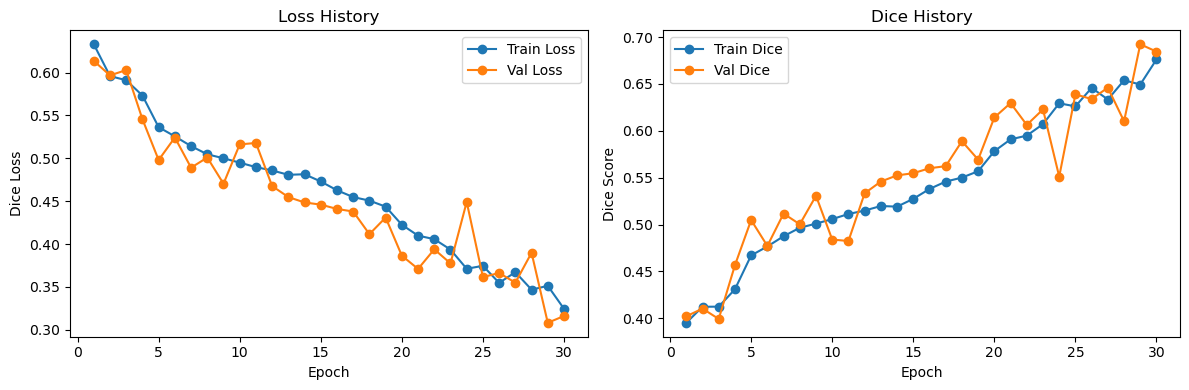

In [15]:
def plot_training_curves(train_losses, val_losses, train_dices, val_dices, save_path=None):
    epochs = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, train_losses, marker="o", label="Train Loss")
    axes[0].plot(epochs, val_losses, marker="o", label="Val Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Dice Loss")
    axes[0].set_title("Loss History")
    axes[0].legend()

    axes[1].plot(epochs, train_dices, marker="o", label="Train Dice")
    axes[1].plot(epochs, val_dices, marker="o", label="Val Dice")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Dice Score")
    axes[1].set_title("Dice History")
    axes[1].legend()

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_training_curves(
    train_losses, val_losses, train_dices, val_dices,
    OUTPUT_DIR / "training_curves_notebook.png"
 )

### 测试集指标与可视化

测试阶段将概率阈值化为二值掩码后，统计像素级混淆矩阵：

| 指标 | 公式 | 解读重点 |
|---|---|---|
| Dice | $2TP/(2TP+FP+FN)$ | 预测区域与真实区域的重叠程度 |
| IoU | $TP/(TP+FP+FN)$ | 比 Dice 更严格的重叠度 |
| Precision | $TP/(TP+FP)$ | 预测为息肉的像素有多少是真的 |
| Recall | $TP/(TP+FN)$ | 真实息肉像素有多少被找回 |
| Accuracy | $(TP+TN)/(TP+TN+FP+FN)$ | 背景很多时容易虚高 |

可视化时先看预测是否大致落在息肉区域，再看边界是否漏掉细长部分或把背景高光误判为前景。

In [16]:
@torch.no_grad()
def compute_segmentation_metrics(model, loader, device, threshold=0.5):
    model.eval()
    preds_all, targets_all = [], []
    for images, masks in loader:
        images = images.to(device)
        logits = model(images)
        preds = (torch.sigmoid(logits).cpu() > threshold).bool()
        preds_all.append(preds.flatten())
        targets_all.append(masks.bool().flatten())

    preds = torch.cat(preds_all)
    targets = torch.cat(targets_all)
    tp = (preds & targets).sum().float()
    fp = (preds & ~targets).sum().float()
    fn = (~preds & targets).sum().float()
    tn = (~preds & ~targets).sum().float()
    eps = 1e-8
    return {
        "dice": (2 * tp / (2 * tp + fp + fn + eps)).item(),
        "iou": (tp / (tp + fp + fn + eps)).item(),
        "precision": (tp / (tp + fp + eps)).item(),
        "recall": (tp / (tp + fn + eps)).item(),
        "accuracy": ((tp + tn) / (tp + tn + fp + fn + eps)).item(),
    }

if best_path.exists():
    model.load_state_dict(torch.load(best_path, map_location=device))

metrics = compute_segmentation_metrics(model, test_loader, device)
for name, value in metrics.items():
    print(f"{name:>9}: {value:.4f}")

     dice: 0.6288
      iou: 0.4586
precision: 0.7208
   recall: 0.5576
 accuracy: 0.9039


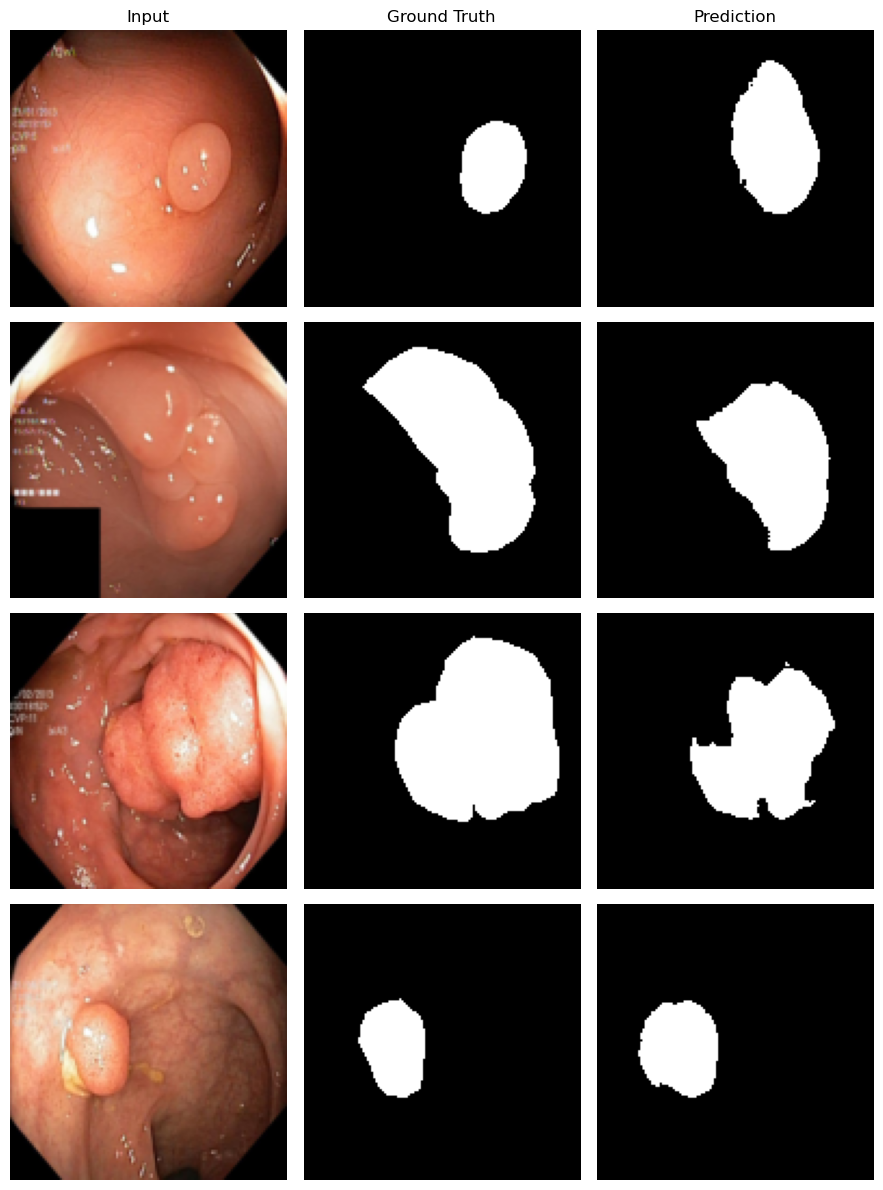

In [17]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, n=4, save_path=None):
    model.eval()
    n = min(n, len(dataset))
    indices = list(range(n))
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    titles = ["Input", "Ground Truth", "Prediction"]
    for col, title in enumerate(titles):
        axes[0, col].set_title(title)

    for row, idx in enumerate(indices):
        image, mask = dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits).squeeze().cpu() > 0.5).float().numpy()

        axes[row, 0].imshow(denormalize(image))
        axes[row, 1].imshow(mask.squeeze().numpy(), cmap="gray")
        axes[row, 2].imshow(pred, cmap="gray")
        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
    plt.show()

visualize_predictions(model, test_set, device, n=4, save_path=OUTPUT_DIR / "predictions_notebook.png")

## 小结

本节完成了一个从任务定义到最小训练的 U-Net 分割流程。

关键结论：

- 语义分割的输出必须保持空间结构。一般多分类任务输出 `(B, K, H, W)`；本 notebook 的 Kvasir-SEG 二分类任务输出 `(B, 1, H, W)`，并与输入图像的高宽一致。
- 下采样扩大感受野，上采样恢复分辨率，跳跃连接补回浅层边界细节。
- `padding=1` 的 `3x3` 卷积不会改变高宽，`MaxPool2d(2)` 让高宽减半，`ConvTranspose2d(2, stride=2)` 让高宽翻倍。
- Dice Loss 直接优化预测区域与真实区域的重叠，适合前景/背景不平衡的医学分割。
- 少量 epoch 的结果只能验证流程，不应被当作最终模型性能。正式实验需要更多 epoch、更完整数据增强和独立测试集报告。

<details>
<summary>思考题：为什么 Accuracy 很高时 Dice 仍可能很低？</summary>

医学分割中背景像素通常占绝大多数。若模型把所有像素都预测为背景，Accuracy 可能仍然很高，因为大部分背景预测正确；但息肉区域完全没有被覆盖，TP 接近 0、FN 很大，Dice 会接近 0。因此分割任务不能只看 Accuracy，还要结合 Dice、IoU、Recall 和可视化边界质量。

</details>

<details>
<summary>思考题：为什么 skip connection 使用 concat，而不是简单相加？</summary>

concat 会保留两路特征的独立通道，让后续卷积自己学习如何融合浅层细节和深层语义。相加要求两路通道数一致，并且会提前把信息混合在一起。U-Net 原始设计使用 concat，更适合展示“编码器细节 + 解码器语义”的融合过程。

</details>

## 参考资料与延伸阅读

- Ronneberger, O., Fischer, P., Brox, T. *U-Net: Convolutional Networks for Biomedical Image Segmentation*. MICCAI 2015.
- Jha, D., et al. *Kvasir-SEG: A Segmented Polyp Dataset*. MMM 2020.
- Milletari, F., Navab, N., Ahmadi, S. *V-Net: Fully Convolutional Neural Networks for Volumetric Medical Image Segmentation*. 3DV 2016.
- CS231n: Convolutional Neural Networks for Visual Recognition, 关于卷积、池化与可视化的基础材料。

可以继续扩展的方向：数据增强、BCE + Dice 复合损失、预训练编码器、Attention U-Net、TransUNet 与 Swin-UNet。